# Supplementary Figure S2: `s02_reliability`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_reliability.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Supplementary Figure S2 documents how the 25 targeted electrodes were chosen and how trustworthy their responses are. Panel a plots the Spearman-Brown corrected split-half reliability of every channel on each animal's array or probe, with the five selected sites highlighted. Panel b converts each selected site's reliability into a calibration noise ceiling, the highest correlation any model could reach. Panel c checks that tuning is stable across days within the calibration phase and across the calibration and control phases. Panel d shows the 5 by 5 tuning-correlation matrix among the selected channels per animal, to confirm they are reliable but not redundant. Panels a, b and d read the channel-selection cache (`preprocessed_data/sup_reliability_channel_selection_cache.pkl`, built from the raw encoding files because the all-channel data are not in the standard preproc cache); panel c reads `loader.load_tuning_stability()`.

## What the script says about itself

Supp fig (reliability) - channel selection, response reliability, NSD noise ceiling.

Four panels covering how the 25 targeted electrodes were chosen and how reliable they are:

- **(a)** Split-half reliability by channel: per monkey, every channel on the array/probe (grey) with the five TARGETED sites highlighted in the animal color and a median line. Selection kept the most reliable AND tuning-diverse channels. Reliability = Spearman-Brown-corrected split-half r (2r/(1+r)) from the raw encoding HDF5.
- **(b)** Per-electrode calibration-phase noise ceiling for the 25 targeted channels: the maximum model-data Pearson r for the trial-averaged calibration response, computed from the SAME calibration data as panel a as sqrt(Spearman-Brown split-half reliability) (the NSD nc_r identity). All five animals have a valid ceiling (control-phase ceilings are a separate supplementary figure).
- **(c)** Tuning stability: per-site cross-day (within encoding) and cross-phase (encoding vs control) Pearson over the shared natural images, grouped by region.
- **(d)** Tuning correlation among the five selected channels: per monkey a 5x5 Pearson matrix over the encoding images - selected channels are reliable and tuning-diverse.

Numbered from the manifest. Panel c reads pnc.preproc.loader (load_tuning_stability). Panels a/b/d read the channel-selection cache (preprocessed_data/sup_reliability_channel_selection_cache.pkl, built by scripts/preprocessing/build_sup_reliability_cache.py from the raw encoding HDF5 - the all-channel grey cloud is not in the preproc cache).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`MONKEYS` sets the left-to-right order, with `TAG` and `REGION` providing the one-letter animal codes and area labels used in tick labels. `CMAP` for panel d is a purple-orange diverging map, deliberately not the red-blue reserved elsewhere for accentuation levels. `W` is the bar width for the paired bars in panel c.

In [2]:
import os

import pickle

import numpy as np

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

from matplotlib.patches import Patch

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR, save_fig,
                       MONKEY_COLORS)

apply_figure_style()

_M = _fig('reliability'); STEM = output_name('reliability')



CS_CACHE = os.path.join(str(paths.preprocessed_data()), 'sup_reliability_channel_selection_cache.pkl')

MONKEYS = ['red', 'paul', 'venus', 'leap', 'three0']

TAG = {'red': 'R', 'paul': 'P', 'venus': 'V', 'leap': 'L', 'three0': 'T'}

REGION = {'red': 'aIT', 'paul': 'cIT', 'venus': 'V3/V4', 'leap': 'STS', 'three0': 'STS'}

CMAP = 'PuOr_r'                       # diverging, NOT the red/blue reserved for levels

FS_LET, FS_TITLE, FS_AX, FS_TICK, FS_ANNOT = 14, 9.5, 6.5, 6.0, 5.5

FS_XTICK_A, FS_XTICK_BC = 8.5, 7.0        # bigger x-tick labels: region names (a) / per-electrode (b,c)

W = 0.36

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

### `calibration_ceilings(cs)`

Per targeted channel: calibration-phase noise ceiling = the maximum model-data Pearson r for the trial-averaged calibration response = sqrt(Spearman-Brown split-half reliability) (the NSD nc_r identity, on the calibration data). Uses the SAME per-channel reliabilities as panel a, so all five animals have a valid ceiling (control-phase ceilings are a separate supplementary figure).

For each selected channel, takes the square root of its clipped split-half reliability as the calibration-phase noise ceiling. This uses exactly the reliabilities plotted in panel a, so every animal has a valid ceiling here (control-phase ceilings are a separate supplementary figure).

In [3]:
# ---- data: panel b calibration-phase noise ceiling --------------------------
def calibration_ceilings(cs):
    """Per targeted channel: calibration-phase noise ceiling = the maximum model-data Pearson r
    for the trial-averaged calibration response = sqrt(Spearman-Brown split-half reliability)
    (the NSD nc_r identity, on the calibration data). Uses the SAME per-channel reliabilities as
    panel a, so all five animals have a valid ceiling (control-phase ceilings are a separate
    supplementary figure)."""
    out = []
    for mk in MONKEYS:
        rel = cs[mk]['rel']
        for u in cs[mk]['sel']:
            out.append(dict(monkey=mk, unit=int(u), nc=float(np.sqrt(np.clip(rel[u], 0.0, 1.0)))))
    return out

### `load_channel_selection()`

---- data: panels a/d (channel-selection cache; built from the raw encoding HDF5) ----

Unpickles the channel-selection cache; the error hint names the script that builds it.

In [4]:
# ---- data: panels a/d (channel-selection cache; built from the raw encoding HDF5) ----
def load_channel_selection():
    path = paths.require(CS_CACHE, hint='python scripts/preprocessing/build_sup_reliability_cache.py')
    with open(path, 'rb') as f:
        return pickle.load(f)

### `panel_a(ax, cs)`

---- panel a: split-half reliability by channel -----------------------------

Per animal, scatters all finite channel reliabilities in light gray, then the five selected sites in the animal's color, and draws a dotted line at the lowest reliability among the selected five.

In [5]:
# ---- panel a: split-half reliability by channel -----------------------------
def panel_a(ax, cs):
    rng = np.random.default_rng(1)
    for i, m in enumerate(MONKEYS):
        rel = cs[m]['rel']; rel_ok = rel[np.isfinite(rel)]
        ax.scatter(i + rng.uniform(-0.28, 0.28, len(rel_ok)), rel_ok, s=5,
                   color='#CFCFCF', alpha=0.55, edgecolors='none', zorder=2)
        rs = rel[cs[m]['sel']]
        lo = np.nanmin(rs)
        ax.plot([i - 0.34, i + 0.34], [lo, lo], color=MONKEY_COLORS[m], lw=1.0,
                ls=':', alpha=0.8, zorder=3)
        ax.scatter(i + rng.uniform(-0.15, 0.15, len(rs)), rs, s=26,
                   color=MONKEY_COLORS[m], alpha=0.95, edgecolors='white',
                   linewidth=0.7, zorder=5)
    ax.set_xticks(range(5))
    ax.set_xticklabels([f'{TAG[m]} {REGION[m]}' for m in MONKEYS], fontsize=FS_XTICK_A)
    for t, m in zip(ax.get_xticklabels(), MONKEYS):
        t.set_color(MONKEY_COLORS[m]); t.set_fontweight('bold')
    ax.set_xlim(-0.6, 4.6); ax.set_ylim(-0.3, 1.0)
    ax.set_ylabel('Spearman-Brown\nsplit-half reliability (r)', fontsize=FS_AX)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.scatter([], [], s=26, color='#888888', edgecolors='white', linewidth=0.7,
               label='Targeted (5/monkey)')
    ax.scatter([], [], s=5, color='#CFCFCF', label='All channels')
    ax.legend(loc='lower center', fontsize=FS_ANNOT, frameon=False, ncol=2,
              handletextpad=0.3, columnspacing=1.0, borderpad=0.2)

### `panel_b(ax, sites)`

---- panel b: per-site noise ceiling ----------------------------------------

One bar per selected site grouped by animal, with a hatched placeholder and an "n/a" tag for any site whose ceiling is undefined. Draws a dashed line at the mean ceiling and returns that mean.

In [6]:
# ---- panel b: per-site noise ceiling ----------------------------------------
def panel_b(ax, sites):
    x, ticks, bounds, centers = 0, [], {}, {}
    for mk in MONKEYS:
        ss = [s for s in sites if s['monkey'] == mk]; start = x; c = MONKEY_COLORS[mk]
        for s in ss:
            if np.isfinite(s['nc']):
                ax.bar(x, s['nc'], 0.8, color=c, edgecolor='white', linewidth=0.4, zorder=3)
            else:
                ax.bar(x, 1.0, 0.8, color=c, alpha=0.16, edgecolor=c, linewidth=0.4,
                       hatch='////', zorder=2)
                ax.text(x, 0.03, 'n/a', ha='center', va='bottom', rotation=90,
                        fontsize=FS_ANNOT - 0.5, color=c)
            ticks.append((x, f'{TAG[mk]}{s["unit"]}', c)); x += 1
        bounds[mk] = (start - 0.5, x - 0.5); centers[mk] = (start + x - 1) / 2; x += 0.8
    ok = [s['nc'] for s in sites if np.isfinite(s['nc'])]
    mean_nc = float(np.mean(ok))
    ax.axhline(mean_nc, color='#111', ls='--', lw=0.8, zorder=4)
    ax.text(1.0, 1.015, f'mean r = {mean_nc:.2f}', transform=ax.transAxes, ha='right',
            va='bottom', fontsize=FS_ANNOT, fontfamily=FONT_FAMILY)
    ax.set_xticks([t[0] for t in ticks])
    ax.set_xticklabels([t[1] for t in ticks], rotation=90, fontsize=FS_XTICK_BC)
    for tk, t in zip(ax.get_xticklabels(), ticks):
        tk.set_color(t[2])
    ax.set_ylim(0, 1.0); ax.set_xlim(-0.8, x - 0.8)
    ax.set_ylabel('Calibration noise ceiling (Pearson r)', fontsize=FS_AX)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    return mean_nc

### `panel_c(ax, ts)`

---- panel c: tuning stability ----------------------------------------------

Paired bars per site: the cross-day correlation (hatched, translucent) and the cross-phase correlation (solid), with a legend explaining the two fills.

In [7]:
# ---- panel c: tuning stability ----------------------------------------------
def panel_c(ax, ts):
    sites = ts['sites']
    x, ticks, bounds, centers = 0, [], {}, {}
    for mk in MONKEYS:
        ss = [s for s in sites if s['monkey'] == mk]; start = x; c = MONKEY_COLORS[mk]
        for s in ss:
            ax.bar(x - W / 2, s['cross_day'], W, color=c, alpha=0.42, hatch='////',
                   edgecolor=c, linewidth=0.4, zorder=3)
            ax.bar(x + W / 2, s['cross_phase'], W, color=c, edgecolor='white',
                   linewidth=0.4, zorder=3)
            ticks.append((x, f'{TAG[mk]}{s["unit"]}', c)); x += 1
        bounds[mk] = (start - 0.5, x - 0.5); centers[mk] = (start + x - 1) / 2; x += 0.8
    ax.set_xticks([t[0] for t in ticks])
    ax.set_xticklabels([t[1] for t in ticks], rotation=90, fontsize=FS_XTICK_BC)
    for tk, t in zip(ax.get_xticklabels(), ticks):
        tk.set_color(t[2])
    ax.set_ylim(0, 1.0); ax.set_xlim(-0.8, x - 0.8)
    ax.set_ylabel('Tuning correlation (Pearson r)', fontsize=FS_AX)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.legend(handles=[Patch(fc='#888', hatch='////', alpha=0.42, ec='#888',
                             label='cross-day (within encoding)'),
                       Patch(fc='#888', ec='white', label='cross-phase (encoding vs control)')],
              loc='upper right', fontsize=FS_ANNOT, frameon=False, handlelength=1.1,
              handletextpad=0.4, labelspacing=0.25, borderpad=0.2)

### `panel_d(fig, gs_d, cs)`

---- panel d: 5x5 tuning-correlation heatmaps -------------------------------

Five small heatmaps, one per animal, of the tuning correlation among the selected channels, with each value printed in the cell (white text on strong colors) and the diagonal outlined. Returns the last image handle for the shared colorbar and the list of axes.

In [8]:
# ---- panel d: 5x5 tuning-correlation heatmaps -------------------------------
def panel_d(fig, gs_d, cs):
    gsD = GridSpecFromSubplotSpec(1, 5, subplot_spec=gs_d, wspace=0.42)
    im = None
    axes = []
    for i, m in enumerate(MONKEYS):
        ax = fig.add_subplot(gsD[0, i]); axes.append(ax)
        tc = cs[m]['tc']; sel = cs[m]['sel']; n = len(sel)
        im = ax.imshow(tc, cmap=CMAP, vmin=-1, vmax=1, aspect='equal')
        for r in range(n):
            for c in range(n):
                ax.text(c, r, f'{tc[r, c]:.2f}', ha='center', va='center',
                        fontsize=5.5, fontfamily=FONT_FAMILY,
                        color=('white' if abs(tc[r, c]) > 0.6 else '#222222'))
            ax.add_patch(plt.Rectangle((r - 0.5, r - 0.5), 1, 1, fill=False,
                                       edgecolor='#333333', lw=0.8))
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(sel, fontsize=5.0, rotation=90)
        ax.set_yticklabels(sel, fontsize=5.0)
        ax.tick_params(length=0)
        ax.set_title(f'{TAG[m]} {REGION[m]}', fontsize=FS_TITLE - 0.5, fontfamily=FONT_FAMILY,
                     fontweight='bold', color=MONKEY_COLORS[m], pad=3)
        for s in ax.spines.values():
            s.set_visible(False)
    return im, axes

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

The figure is two-column width and 198 mm tall, a four-row GridSpec with panels a, b and c each taking a full row and the row of five heatmaps at the bottom. Panel titles and letters are added after a canvas draw so they can be placed relative to the actual axes.

In [9]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the tuning-stability data, the channel-selection cache, and derives the per-site calibration ceilings.

In [10]:
ts = L.load_tuning_stability()
cs = load_channel_selection()
sites = calibration_ceilings(cs)

**Step 2**

Creates the figure and GridSpec, draws panels a, b and c into the first three rows, draws the heatmap row, and nudges the heatmaps down slightly so their titles clear panel c's tick labels.

In [11]:
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, 198 * MM), facecolor=FIG_FACECOLOR)
gs = GridSpec(4, 1, figure=fig, left=0.085, right=0.965, top=0.95, bottom=0.055,
              height_ratios=[1.05, 1.0, 1.0, 0.72], hspace=0.50)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[1, 0])
axC = fig.add_subplot(gs[2, 0])
panel_a(axA, cs)
mean_nc = panel_b(axB, sites)
panel_c(axC, ts)
im, axesD = panel_d(fig, gs[3, 0], cs)
for a in axesD:                     # nudge panel D down so its title clears panel C's x-tick labels
    p = a.get_position(); a.set_position([p.x0, p.y0 - 0.018, p.width, p.height])

**Step 3**

Hides the top and right spines of the three bar-and-scatter panels.

In [12]:
for a in (axA, axB, axC):
    for s in ('top', 'right'):
        a.spines[s].set_visible(False)

**Step 4**

Draws the canvas, adds a colorbar to the right of the heatmap row, then places a centered title and a bold letter above each of the four panels.

In [13]:
fig.canvas.draw()

# colorbar for panel d, anchored to the right of the heatmap row
bbD = axesD[-1].get_position()
cax = fig.add_axes([bbD.x1 + 0.012, bbD.y0, 0.010, bbD.height])
cb = fig.colorbar(im, cax=cax); cb.ax.tick_params(labelsize=FS_ANNOT)
cb.set_label('tuning correlation (r)', fontsize=FS_AX)
cb.set_ticks([-1, -0.5, 0, 0.5, 1])

# panel titles (over each axis / row) + bold letters
row_titles = [(axA, 'a', 'Split-half reliability by channel'),
              (axB, 'b', 'Calibration noise ceiling per electrode'),
              (axC, 'c', 'Tuning stability across days and phases')]
for a, letter, title in row_titles:
    bb = a.get_position()
    fig.text((bb.x0 + bb.x1) / 2, bb.y1 + 0.010, title, ha='center', va='bottom',
             fontsize=FS_TITLE, fontfamily=FONT_FAMILY)
    fig.text(0.012, bb.y1 + 0.026, letter, ha='left', va='top', fontsize=FS_LET,
             fontweight='bold', fontfamily=FONT_FAMILY)

# panel d title + letter (over the heatmap row)
bbL, bbR = axesD[0].get_position(), axesD[-1].get_position()
dx0, dx1, dy1 = bbL.x0, bbR.x1, bbL.y1
fig.text((dx0 + dx1) / 2, dy1 + 0.026, 'Tuning correlation among selected channels',
         ha='center', va='bottom', fontsize=FS_TITLE, fontfamily=FONT_FAMILY)
fig.text(0.012, dy1 + 0.042, 'd', ha='left', va='top', fontsize=FS_LET,
         fontweight='bold', fontfamily=FONT_FAMILY)

Text(0.012, 0.20103601478018154, 'd')

**Step 5**

Saves the figure, closes it, and prints the mean calibration noise ceiling.

In [14]:
path = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print(f'mean calibration noise ceiling (25 sites) = {mean_nc:.4f}')
print('Saved ->', path)
png = path

mean calibration noise ceiling (25 sites) = 0.8759
Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s02_reliability.png


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s02_reliability.png` in the output directory).

In panel a the highlighted sites sit at the top of each gray cloud, and the dotted line marks how far down the selection reached. Panel b's dashed line is the mean ceiling across all 25 sites (0.88 in the caption). In panel d, off-diagonal values well below one mean the selected channels have distinct tuning.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s02_reliability.png


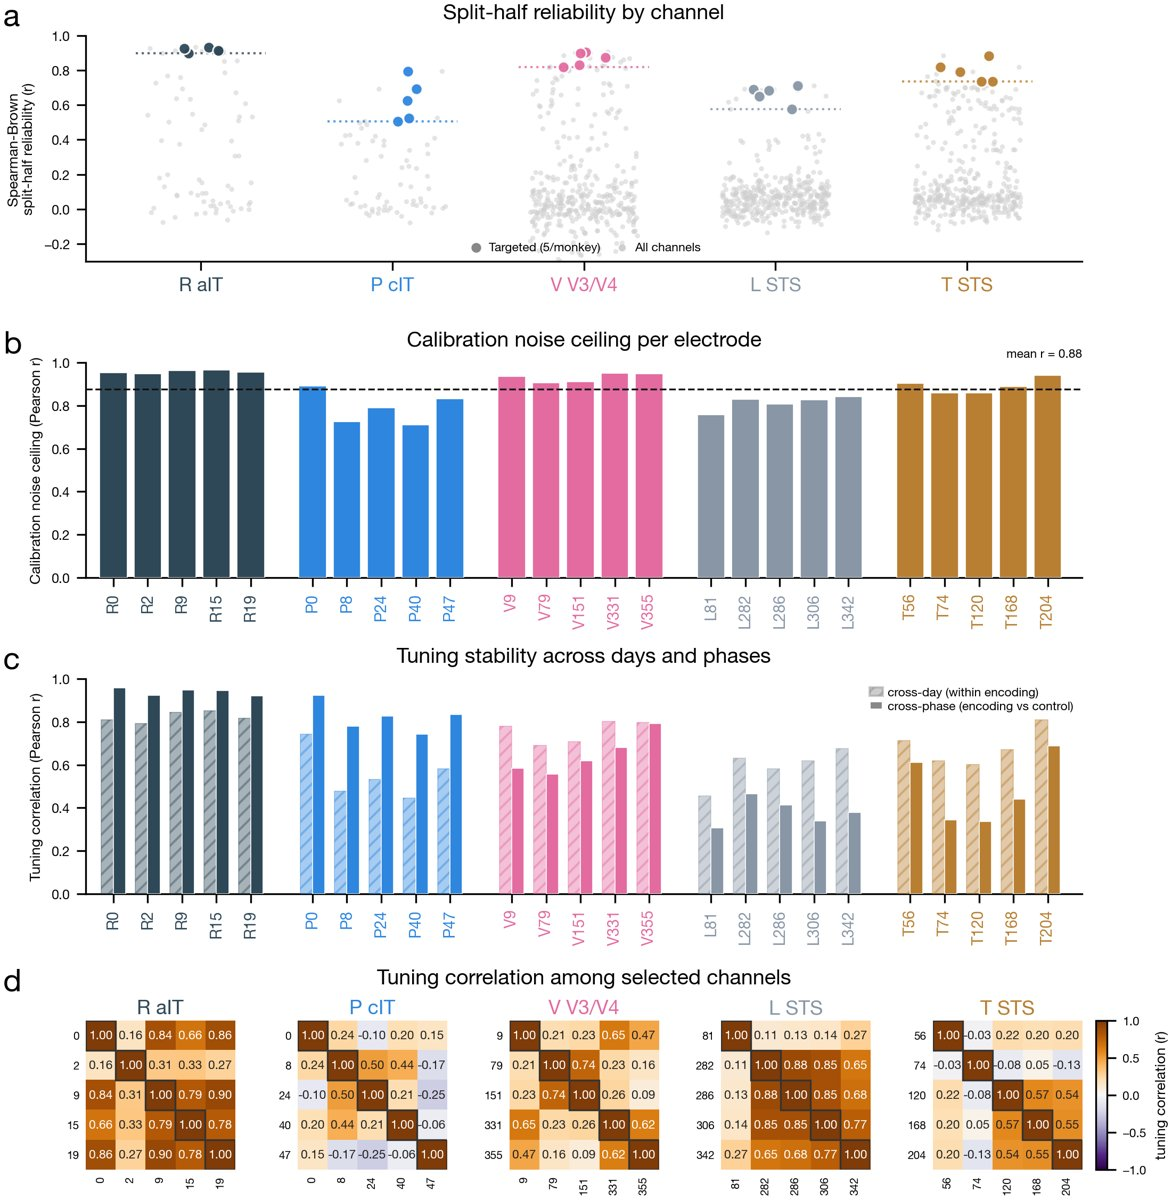

In [15]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S2. Response reliability and NSD noise ceiling.** Characterization of how the 25 targeted electrodes were selected and how reliably they respond, across the 5 macaques (Monkey R aIT, Monkey P cIT, Monkey V V3/V4, Monkey L STS, Monkey T STS). (A) Split-half response reliability by channel. For each animal, we plot the Spearman-Brown-corrected split-half reliability ($r$; $2r/(1+r)$ over repeats occurring during the calibration phase) for every array/probe channel (gray). The 5 targeted sites are highlighted per animal and a dotted line marks the minimum reliability of the 5 selected sites. (B) Calibration noise ceiling per electrode. Bars show the per-site ceiling (Pearson $r$), the maximum model-data correlation for the trial-averaged calibration response, computed from the same calibration data as (A) as $\sqrt{r_{\mathrm{split\text{-}half}}}$ (the NSD $\mathrm{nc\_r}$ identity; Allen et al., 2022), for each of the 25 sites, grouped and colored by animal; all five animals have a valid ceiling; control-phase noise ceilings, used for the control analyses, are reported separately. Dashed line: mean $r = 0.88$ across all 25 sites. (C) Tuning stability measured per site: cross-day (within the calibration phase, dashed fill) and cross-phase (calibration vs control phases, solid fill) Pearson $r$ of responses over the shared calibration images, grouped by animal. (D) The tuning correlations among the 5 targeted channels per animal: $5\times5$ correlation matrices (Pearson $r$) over calibration-phase images, confirming that selected channels are reliable and have relatively diverse tuning profiles.